Original shape: (2073, 11)
Original columns: ['Date', 'Global_LSCI', 'LSCI_lag7', 'LSCI_lag14', 'LSCI_lag28', 'LSCI_rolling14', 'IIP_Value', 'IIP_lag7', 'IIP_lag14', 'IIP_lag28', 'IIP_rolling14']

Refined economic expert features created successfully.
Saved to: economic_expert_features_refined.csv

Final shape: (2073, 8)

First 5 rows:
        Date  lsci_current  iip_current  lsci_sustained  iip_sustained  \
0 2020-02-29     -1.315424    -0.273911       -1.311394      -0.276798   
1 2020-03-01     -1.315424    -1.276958       -1.311394      -0.349914   
2 2020-03-02     -1.315424    -1.276958       -1.311394      -0.423030   
3 2020-03-03     -1.315424    -1.276958       -1.311394      -0.496146   
4 2020-03-04     -1.315424    -1.276958       -1.311394      -0.569262   

   trade_pressure_index  economic_expert_score economic_risk_label  
0             -0.794439              -0.794382        Low Pressure  
1             -1.109976              -1.063423        Low Pressure  
2         

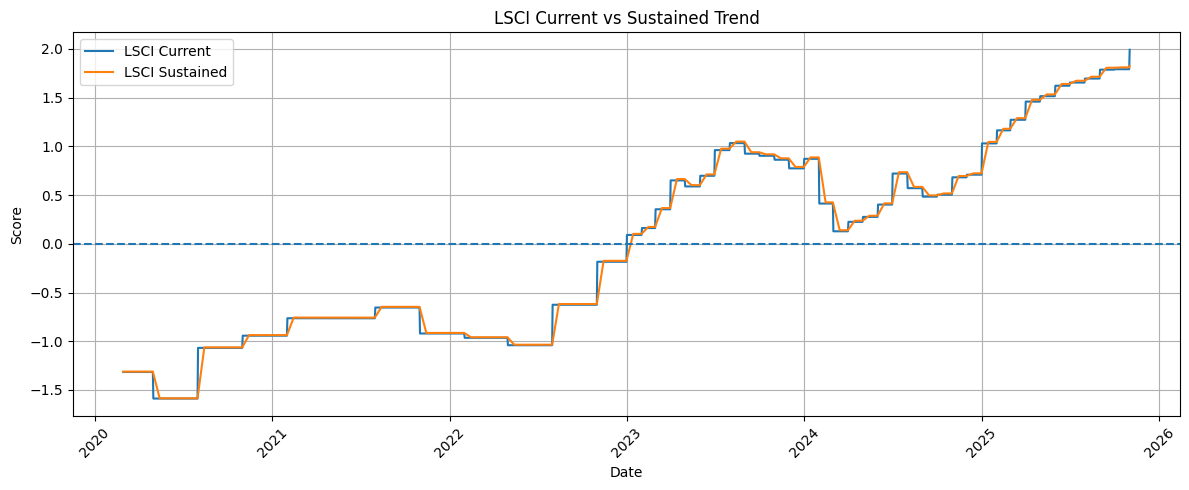

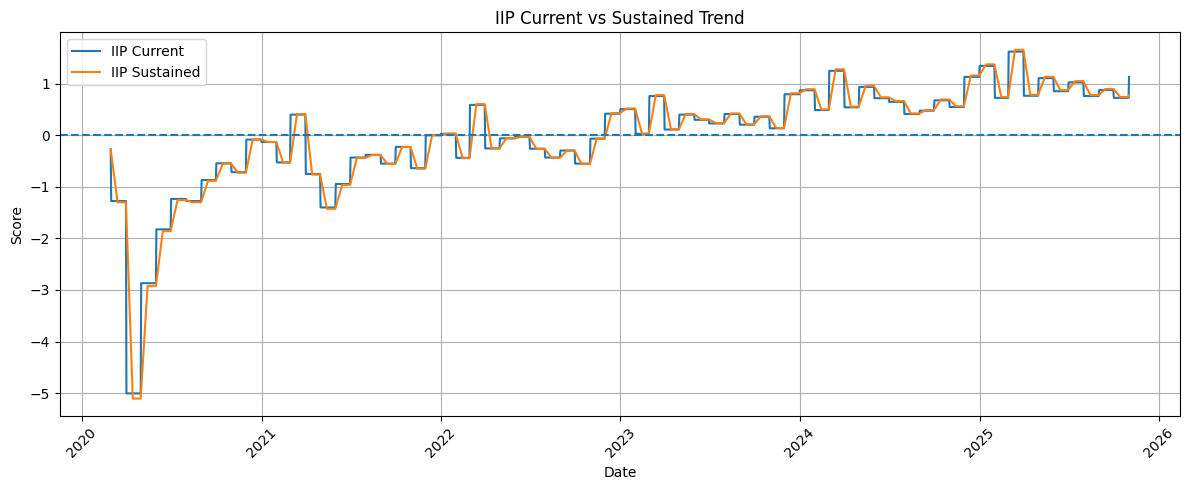

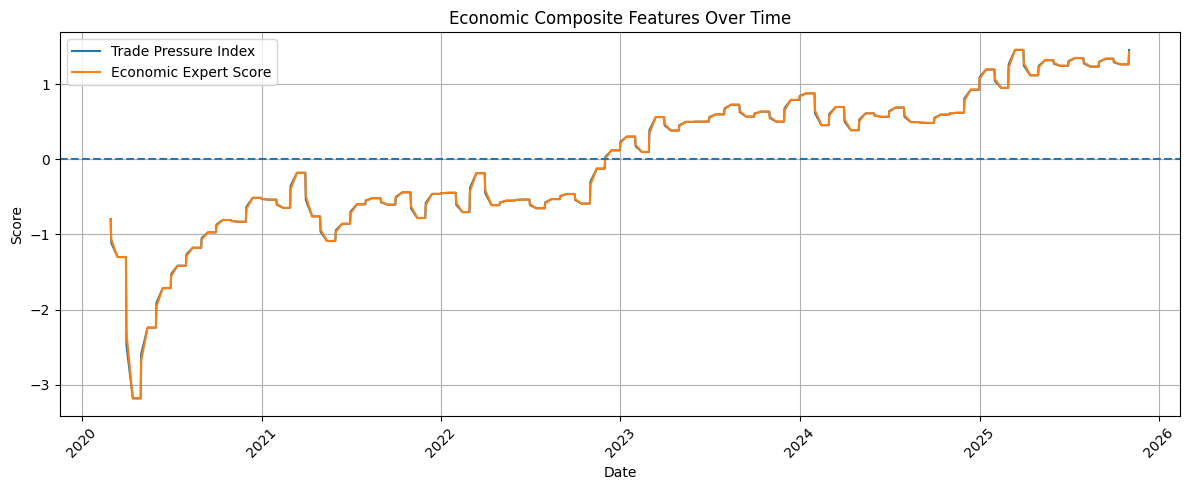

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

INPUT_CSV = "final_economic_features.csv"
OUTPUT_CSV = "economic_expert_features_refined.csv"


df = pd.read_csv(INPUT_CSV)

print("Original shape:", df.shape)
print("Original columns:", df.columns.tolist())

required_cols = [
    "Date",
    "Global_LSCI",
    "LSCI_rolling14",
    "IIP_Value",
    "IIP_rolling14"
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

numeric_cols = [
    "Global_LSCI",
    "LSCI_rolling14",
    "IIP_Value",
    "IIP_rolling14"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols] = df[numeric_cols].interpolate(method="linear", limit_direction="both")
df[numeric_cols] = df[numeric_cols].fillna(0)


df["lsci_current"] = df["Global_LSCI"]
df["iip_current"] = df["IIP_Value"]

df["lsci_sustained"] = df["LSCI_rolling14"]
df["iip_sustained"] = df["IIP_rolling14"]

# Trade pressure from current + sustained economic conditions
df["trade_pressure_index"] = (
    0.30 * df["lsci_current"] +
    0.30 * df["iip_current"] +
    0.20 * df["lsci_sustained"] +
    0.20 * df["iip_sustained"]
)

# Final expert score with slightly higher importance to sustained context
df["economic_expert_score"] = (
    0.25 * df["lsci_current"] +
    0.25 * df["iip_current"] +
    0.25 * df["lsci_sustained"] +
    0.25 * df["iip_sustained"]
)

df["economic_expert_score"] = df["economic_expert_score"].clip(lower=-5, upper=5)

# -------------------------------
# 5. Risk labeling
# -------------------------------
def economic_risk_label(score):
    if score > 0.8:
        return "High Pressure"
    elif score > 0.2:
        return "Moderate Pressure"
    else:
        return "Low Pressure"

df["economic_risk_label"] = df["economic_expert_score"].apply(economic_risk_label)

# -------------------------------
# 6. Final selected columns
# -------------------------------
final_cols = [
    "Date",
    "lsci_current",
    "iip_current",
    "lsci_sustained",
    "iip_sustained",
    "trade_pressure_index",
    "economic_expert_score",
    "economic_risk_label"
]

economic_features = df[final_cols].copy()

# -------------------------------
# 7. Save output
# -------------------------------
economic_features.to_csv(OUTPUT_CSV, index=False)

print("\nRefined economic expert features created successfully.")
print("Saved to:", OUTPUT_CSV)
print("\nFinal shape:", economic_features.shape)

print("\nFirst 5 rows:")
print(economic_features.head())

print("\nLast 5 rows:")
print(economic_features.tail())

print("\nFinal columns:")
print(economic_features.columns.tolist())

print("\nSummary statistics:")
print(economic_features.drop(columns=["Date", "economic_risk_label"]).describe())

# -------------------------------
# 8. Visualizations
# -------------------------------
plt.figure()
plt.plot(economic_features["Date"], economic_features["lsci_current"], label="LSCI Current")
plt.plot(economic_features["Date"], economic_features["lsci_sustained"], label="LSCI Sustained")
plt.axhline(0, linestyle="--")
plt.title("LSCI Current vs Sustained Trend")
plt.xlabel("Date")
plt.ylabel("Score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(economic_features["Date"], economic_features["iip_current"], label="IIP Current")
plt.plot(economic_features["Date"], economic_features["iip_sustained"], label="IIP Sustained")
plt.axhline(0, linestyle="--")
plt.title("IIP Current vs Sustained Trend")
plt.xlabel("Date")
plt.ylabel("Score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(economic_features["Date"], economic_features["trade_pressure_index"], label="Trade Pressure Index")
plt.plot(economic_features["Date"], economic_features["economic_expert_score"], label="Economic Expert Score")
plt.axhline(0, linestyle="--")
plt.title("Economic Composite Features Over Time")
plt.xlabel("Date")
plt.ylabel("Score")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()